<a href="https://colab.research.google.com/github/lakshmigojanece/ZENDS-Communications-is-a-virtual-telecom-company/blob/main/AI_Customer_Support_Copilot_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers pandas numpy


In [ ]:
#collect 20000 datasets

In [ ]:
import pandas as pd
import random
import uuid

# Products and categories
products = {
    "Mobile Connectivity": [
        "Prepaid Basic", "Prepaid Plus", "Prepaid Unlimited",
        "Postpaid Silver", "Postpaid Gold", "Postpaid Platinum"
    ],
    "Home & Office Internet": [
        "ZENDFiber Home 100 Mbps", "ZENDFiber Home 300 Mbps", "ZENDFiber Home 1 Gbps",
        "ZENDOffice Net 200", "ZENDOffice Net 500", "ZENDOffice Net 1G"
    ],
    "Business Connectivity": [
        "ZENDBiz Connect 100", "ZENDBiz Connect 500", "ZENDBiz Connect 1G",
        "ZENDEnterprise Ultra", "ZENDEnterprise Dedicated"
    ],
    "Cloud & Data Center Services": [
        "ZENDCloud VM Basic", "ZENDCloud VM Pro", "ZENDCloud VM Enterprise",
        "ZENDStorage 1TB", "ZENDStorage 10TB", "ZENDArchive Storage"
    ],
    "IoT & Smart Solutions": [
        "ZENDSmart Traffic", "ZENDSmart Lighting", "ZENDSmart Parking",
        "ZENDIndustrial Sensor", "ZENDFleet IoT"
    ]
}

countries = ["USA", "India", "Singapore", "Thailand"]
user_types = ["individual", "enterprise"]
intents = ["Billing", "Refund", "Technical", "Complaint", "Product Inquiry"]

templates = {
    "Billing": [
        "Invoice {invoice_id}: I was charged extra for my {product} plan in {country}.",
        "Invoice {invoice_id}: My {product} bill in {country} seems incorrect.",
        "Invoice {invoice_id}: Explain charges for {product} under {user_type} account."
    ],
    "Refund": [
        "Refund request {ticket_id}: I want refund for {product} used in {country}.",
        "Refund ticket {ticket_id}: Why no refund for {product} in {country}?",
        "Ticket {ticket_id}: Please process refund for {product}."
    ],
    "Technical": [
        "Ticket {ticket_id}: My {product} service in {country} is not working.",
        "Issue ID {ticket_id}: Facing problem with {product}.",
        "Ticket {ticket_id}: Cannot access {product} for {user_type} account."
    ],
    "Complaint": [
        "Complaint {ticket_id}: I am disappointed with {product} in {country}.",
        "Ticket {ticket_id}: Very frustrated with {product} service.",
        "Complaint ID {ticket_id}: Poor experience with {product}."
    ],
    "Product Inquiry": [
        "Inquiry {ticket_id}: Tell me about {product} plans in {country}.",
        "Request {ticket_id}: Does {product} support premium features?",
        "Inquiry ID {ticket_id}: Need pricing details of {product}."
    ]
}

intent_sentiments_prob = {
    "Complaint": (["Angry", "Neutral"], [0.6, 0.4]),
    "Product Inquiry": (["Neutral", "Happy"], [0.7, 0.3]),
    "Billing": (["Neutral", "Angry"], [0.8, 0.2]),
    "Refund": (["Neutral", "Angry"], [0.8, 0.2]),
    "Technical": (["Neutral", "Angry"], [0.8, 0.2])
}

# ------------------------------------
# UNIQUE GENERATION USING SET
# ------------------------------------

unique_data = set()

while len(unique_data) < 20000:

    intent = random.choice(intents)
    category = random.choice(list(products.keys()))
    product = random.choice(products[category])
    country = random.choice(countries)
    user_type = random.choice(user_types)

    invoice_id = "INV" + str(uuid.uuid4())[:8]
    ticket_id = "TKT" + str(uuid.uuid4())[:8]

    sentiment_options, probs = intent_sentiments_prob[intent]
    sentiment = random.choices(sentiment_options, weights=probs)[0]

    template = random.choice(templates[intent])

    text = template.format(
        product=product,
        country=country,
        user_type=user_type,
        invoice_id=invoice_id,
        ticket_id=ticket_id
    )

    unique_data.add((text, intent, sentiment))

# Convert to dataframe
df = pd.DataFrame(list(unique_data), columns=["text", "intent", "sentiment"])

print("Final Shape:", df.shape)
print("Duplicate Count:", df.duplicated().sum())

df.to_csv("ZenDS_Communications_20k_queries_final.csv", index=False)

print("✅ 20000 UNIQUE dataset generated successfully")


Final Shape: (20000, 3)
Duplicate Count: 0
✅ 20000 UNIQUE dataset generated successfully


In [ ]:
from google.colab import files
files.download("ZenDS_Communications_20k_queries_final.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#EDA(EXploratory Data Analysis)

In [ ]:
df.shape

(20000, 3)

In [ ]:
df.columns

Index(['text', 'intent', 'sentiment'], dtype='object')

In [ ]:
df.isnull().sum()

,0
text,0
intent,0
sentiment,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['intent'].value_counts()

,count
intent,
Refund,4051
Technical,4032
Complaint,4015
Product Inquiry,3959
Billing,3943


In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
Neutral,14078
Angry,4748
Happy,1174


In [ ]:
df['text'].str.len()


,text
0,84
1,74
2,71
3,85
4,65
...,...
19995,72
19996,77
19997,75
19998,70


<Axes: >

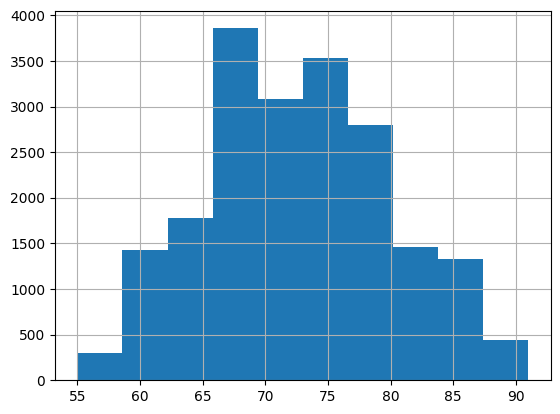

In [ ]:
df['text'].str.len().hist()


In [ ]:
pd.crosstab(df['intent'],df['sentiment'])

sentiment,Angry,Happy,Neutral
intent,,,
Billing,771,0,3172
Complaint,2365,0,1650
Product Inquiry,0,1174,2785
Refund,798,0,3253
Technical,814,0,3218


STEP 3 — Intent Classification (Fine Tuning)

Use:

HuggingFace

DistilBERT

FULL working training code for your 20,000 dataset 💯

In [ ]:
#Step 1: Install Libraries

In [ ]:
!pip install -U transformers datasets accelerate


In [ ]:
#Step 2: Import Libraries

In [ ]:
import pandas as pd
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


In [ ]:
#Step 3: Load Your Dataset (20000 No Duplicates)

In [ ]:
df.shape

(20000, 3)

In [ ]:
df

,text,intent,sentiment
0,Invoice INV1eedfa16: I was charged extra for m...,Billing,Angry
1,Complaint TKT28d2a51c: I am disappointed with ...,Complaint,Angry
2,Complaint TKT7052f1bc: I am disappointed with ...,Complaint,Neutral
3,Invoice INVc17fb837: I was charged extra for m...,Billing,Neutral
4,Request TKTd6cb3881: Does Postpaid Gold suppor...,Product Inquiry,Neutral
...,...,...,...
19995,Inquiry TKTaa04834c: Tell me about ZENDOffice ...,Product Inquiry,Neutral
19996,Refund ticket TKTe78603a6: Why no refund for Z...,Refund,Neutral
19997,Complaint TKT4e5cfdea: I am disappointed with ...,Complaint,Angry
19998,Request TKT312e6c5f: Does ZENDOffice Net 200 s...,Product Inquiry,Happy


In [ ]:
#Step 4: Encode Labels

In [ ]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['intent'])


In [ ]:
#Step 5: Train Test Split

In [ ]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42
)


In [ ]:
df.columns

Index(['text', 'intent', 'sentiment', 'label'], dtype='object')

In [ ]:
#Step 6: Convert to HuggingFace Dataset

In [ ]:
train_dataset = Dataset.from_dict({
    "text": train_texts.tolist(),
    "label": train_labels.tolist()
})

val_dataset = Dataset.from_dict({
    "text": val_texts.tolist(),
    "label": val_labels.tolist()
})


In [ ]:
#Step 7: Load Tokenizer

In [ ]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
tokenizer

BertTokenizer(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [ ]:
#Step 8: Tokenization

In [ ]:
def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

In [ ]:
#Step 9: Load Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
#Step 10: Training Arguments (UPDATED WORKING VERSION)

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./intent_model",

    eval_strategy="epoch",      # add this
    save_strategy="epoch",      # must match above
    load_best_model_at_end=True,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3
)


In [ ]:
training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [ ]:
#Step 11: Trainer

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)


In [ ]:
trainer

In [ ]:
#Step 12: Train

In [ ]:
trainer.train()


Epoch,Training Loss,Validation Loss
1,0.000263,0.000096
2,0.000065,0.000032
3,0.000040,0.000023


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3000, training_loss=0.009032676732788483, metrics={'train_runtime': 604.289, 'train_samples_per_second': 79.432, 'train_steps_per_second': 4.965, 'total_flos': 1589693829120000.0, 'train_loss': 0.009032676732788483, 'epoch': 3.0})

In [ ]:
#💻 STEP 12 — Evaluate

In [ ]:
trainer.evaluate()


{'eval_loss': 2.2913072825758718e-05,
 'eval_runtime': 15.0269,
 'eval_samples_per_second': 266.189,
 'eval_steps_per_second': 16.637,
 'epoch': 3.0}

In [ ]:
#🚀 After Training – Save Model

In [ ]:
trainer.save_model("zends_intent_model")
tokenizer.save_pretrained("zends_intent_model")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('zends_intent_model/tokenizer_config.json',
 'zends_intent_model/tokenizer.json')

In [ ]:
!zip -r zends_intent_model.zip zends_intent_model


  adding: zends_intent_model/ (stored 0%)
  adding: zends_intent_model/config.json (deflated 54%)
  adding: zends_intent_model/model.safetensors (deflated 8%)
  adding: zends_intent_model/tokenizer.json (deflated 71%)
  adding: zends_intent_model/tokenizer_config.json (deflated 42%)
  adding: zends_intent_model/training_args.bin (deflated 53%)


In [ ]:
text = "I was charged extra for my Postpaid Gold plan."

inputs = tokenizer(text, return_tensors="pt")
outputs = model(**inputs)

predicted_class_id = torch.argmax(outputs.logits).item()
predicted_label = label_encoder.inverse_transform([predicted_class_id])

print("Predicted Intent:", predicted_label[0])


RuntimeError: Expected all tensors to be on the same device, but got index is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA__index_select)

In [ ]:
sentiment_model("I am very happy with your service")


[{'label': 'POSITIVE', 'score': 0.977362871170044}]

In [ ]:
from transformers import pipeline

sentiment_model = pipeline("sentiment-analysis")

sentiment_model("I am very frustrated with your service")


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'NEGATIVE', 'score': 0.9996931552886963}]